# ViCocktail Dataset Inspection

Inspect complete train, validation, and test splits, analyze frame-length distributions, and compare decoded video with the training augmentation pipeline.

In [1]:
import os
import sys

CURRENT_DIR = os.path.abspath(os.getcwd())
PROJECT_DIR = (
    os.path.dirname(CURRENT_DIR)
    if os.path.basename(CURRENT_DIR) == "experiments"
    else CURRENT_DIR
)

if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

print(f"Project: {PROJECT_DIR}")

Project: d:\projects\VietnameseVSR


In [2]:
import random

import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import HTML, display

from srcs.datasets.transform import VideoTransform, load_video
from srcs.datasets.utils import to_text
from srcs.datasets.vicocktail import load_vicocktail

SEED = 42
SPLITS = ("train", "val", "test")
MEAN = 0.421
STD = 0.165

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

d:\projects\VietnameseVSR\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the complete dataset

The validation split is created by `load_vicocktail` from the original training split. Fractions are explicitly set to `1.0` for all three resulting splits.

In [3]:
dataset = load_vicocktail(
    train_fraction=1.0,
    validation_fraction=1.0,
    test_fraction=1.0,
    splits=SPLITS,
    seed=SEED,
)

for split in SPLITS:
    print(f"{split}: {len(dataset[split]):,} samples")
    print(f"columns: {dataset[split].column_names}")

train: 188,229 samples
columns: ['label', 'length', 'sample_id', 'video', 'video_length']
val: 5,844 samples
columns: ['label', 'length', 'sample_id', 'video', 'video_length']
test: 1,167 samples
columns: ['label', 'length', 'sample_id', 'video', 'video_length']


## Frame-length distribution

These functions use the cached `video_length` metadata and do not decode videos.

In [4]:
def get_frame_lengths(split_dataset):
    return np.asarray(split_dataset["video_length"], dtype=np.int64)


def summarize_frame_lengths(dataset_dict, splits=SPLITS):
    rows = []

    for split in splits:
        lengths = get_frame_lengths(dataset_dict[split])
        rows.append(
            {
                "split": split,
                "samples": lengths.size,
                "total_frames": int(lengths.sum()),
                "min": int(lengths.min()),
                "mean": float(lengths.mean()),
                "std": float(lengths.std()),
                "p25": float(np.quantile(lengths, 0.25)),
                "median": float(np.quantile(lengths, 0.50)),
                "p75": float(np.quantile(lengths, 0.75)),
                "p90": float(np.quantile(lengths, 0.90)),
                "p95": float(np.quantile(lengths, 0.95)),
                "p99": float(np.quantile(lengths, 0.99)),
                "max": int(lengths.max()),
            }
        )

    return pd.DataFrame(rows).set_index("split")


frame_summary = summarize_frame_lengths(dataset)
display(frame_summary.round(2))

,samples,total_frames,min,mean,std,p25,median,p75,p90,p95,p99,max
split,,,,,,,,,,,,
train,188229,23483909,25,124.76,69.99,75.0,112.0,159.0,236.0,252.0,339.0,376
val,5844,727791,25,124.54,67.20,83.0,112.0,152.0,225.0,252.0,340.0,374
test,1167,167142,17,143.22,52.38,104.0,127.0,172.0,247.0,252.0,252.0,252


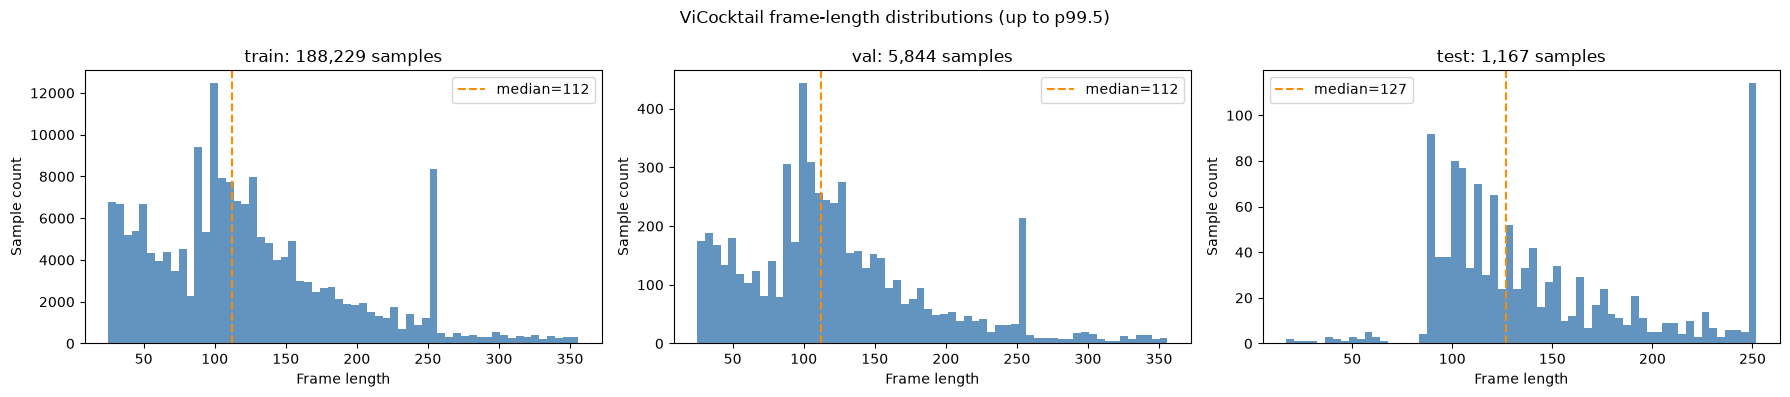

In [5]:
def plot_frame_length_distributions(dataset_dict, splits=SPLITS, bins=60):
    figure, axes = plt.subplots(1, len(splits), figsize=(18, 4), sharey=False)

    for axis, split in zip(axes, splits):
        lengths = get_frame_lengths(dataset_dict[split])
        display_limit = float(np.quantile(lengths, 0.995))
        visible_lengths = lengths[lengths <= display_limit]
        axis.hist(visible_lengths, bins=bins, color="steelblue", alpha=0.85)
        axis.axvline(
            np.median(lengths),
            color="darkorange",
            linestyle="--",
            label=f"median={np.median(lengths):.0f}",
        )
        axis.set_title(f"{split}: {lengths.size:,} samples")
        axis.set_xlabel("Frame length")
        axis.set_ylabel("Sample count")
        axis.legend()

    figure.suptitle("ViCocktail frame-length distributions (up to p99.5)")
    figure.tight_layout()
    plt.show()


plot_frame_length_distributions(dataset)

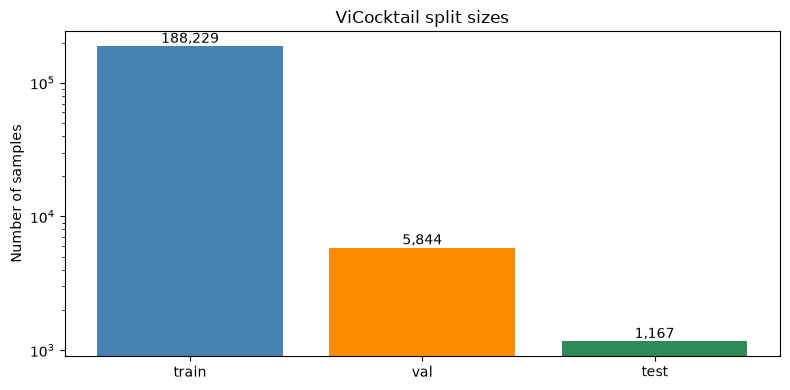

In [6]:
def plot_split_sizes(dataset_dict, splits=SPLITS):
    sizes = [len(dataset_dict[split]) for split in splits]
    figure, axis = plt.subplots(figsize=(8, 4))
    bars = axis.bar(splits, sizes, color=("steelblue", "darkorange", "seagreen"))
    axis.bar_label(bars, labels=[f"{size:,}" for size in sizes])
    axis.set_ylabel("Number of samples")
    axis.set_title("ViCocktail split sizes")
    axis.set_yscale("log")
    figure.tight_layout()
    plt.show()


plot_split_sizes(dataset)

## View dataset samples

In [7]:
def frame_to_image(frame, normalized=False):
    image = frame.detach().cpu().float()

    if normalized:
        image = image.mul(STD).add(MEAN)
    elif image.max() > 1.0:
        image = image.div(255.0)

    image = image.clamp(0.0, 1.0)

    if image.size(0) == 1:
        return image.squeeze(0).numpy()

    return image.permute(1, 2, 0).numpy()


def decode_dataset_sample(split_dataset, index):
    sample = split_dataset[int(index)]
    start_time = sample.get("start_time", 0.0)
    end_time = sample.get("end_time")
    video = load_video(sample["video"], start_time, end_time)
    return sample, video


def show_sample(split_dataset, index, frame_count=8, title=None):
    sample, video = decode_dataset_sample(split_dataset, index)
    indices = np.linspace(0, video.size(0) - 1, frame_count, dtype=int)
    figure, axes = plt.subplots(1, frame_count, figsize=(2.4 * frame_count, 2.8))

    for axis, frame_index in zip(axes, indices):
        axis.imshow(frame_to_image(video[frame_index]), cmap="gray")
        axis.set_title(f"frame {frame_index}")
        axis.axis("off")

    sample_id = to_text(sample.get("sample_id", index))
    label = to_text(sample.get("label", ""))
    figure.suptitle(title or f"{sample_id} | {label}")
    figure.tight_layout()
    plt.show()

    print(f"sample_id: {sample_id}")
    print(f"label: {label}")
    print(f"decoded shape: {tuple(video.shape)}")
    print(f"metadata frame length: {sample.get('video_length')}")

    return sample, video


def show_random_samples(dataset_dict, split, sample_count=2, frame_count=8, seed=SEED):
    generator = np.random.default_rng(seed)
    indices = generator.choice(len(dataset_dict[split]), size=sample_count, replace=False)

    for index in indices:
        show_sample(
            dataset_dict[split],
            int(index),
            frame_count=frame_count,
            title=f"{split} sample {int(index)}",
        )

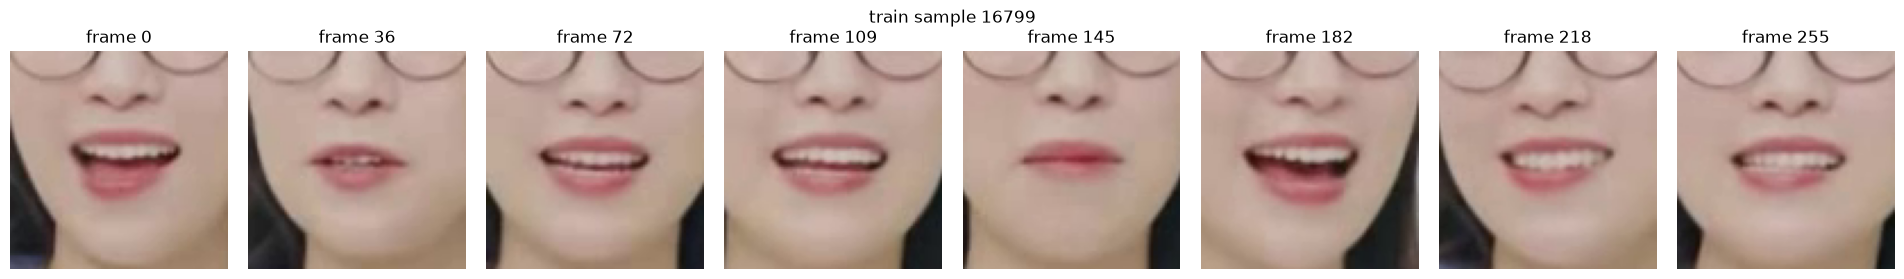

sample_id: rlmuvGjtyrc_00032_000000_2_-1.00
label: cái bản thể này đang làm những cái thói quen gì đang làm những cái hành động gì bản thể này sẽ cư xử ra sao và mình có thể cư xử như thế được không
decoded shape: (256, 3, 96, 96)
metadata frame length: 252


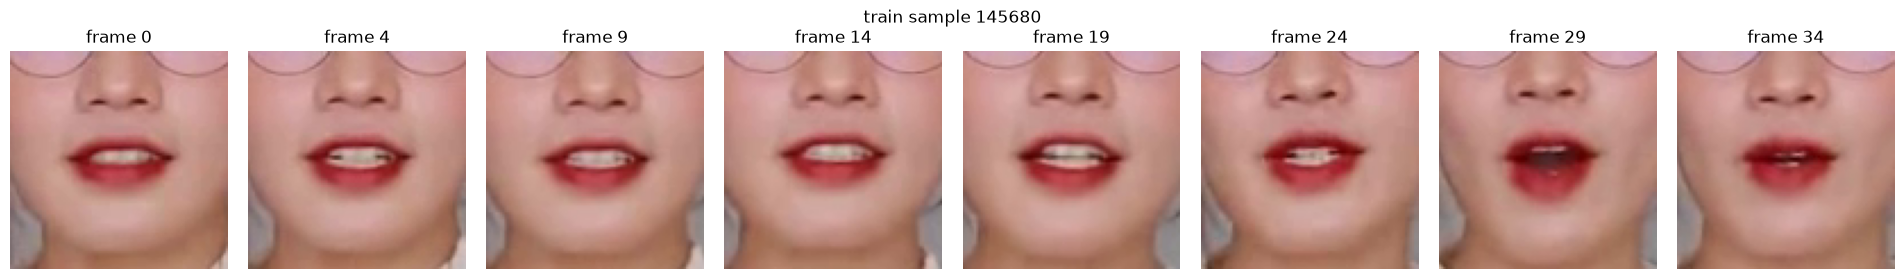

sample_id: PujaInqsUPA_00002_000000_1_-1.00
label: sang đã nhận được rất là nhiều những câu hỏi
decoded shape: (35, 3, 96, 96)
metadata frame length: 35


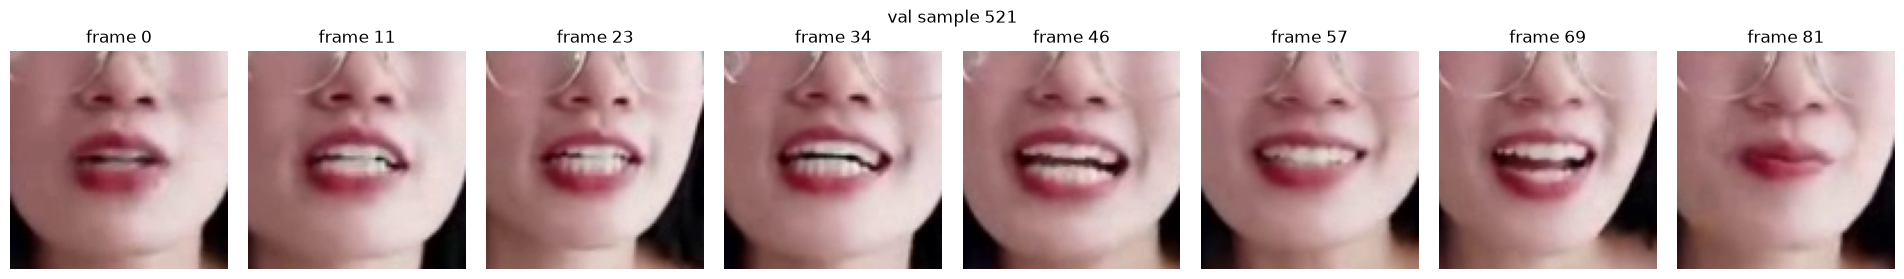

sample_id: Sn5iDL6TlyU_00047_000000_11_-1.00
label: về cái chủ đề đấy à nhưng mà hãy chờ đợi trong tương lai nha
decoded shape: (82, 3, 96, 96)
metadata frame length: 74


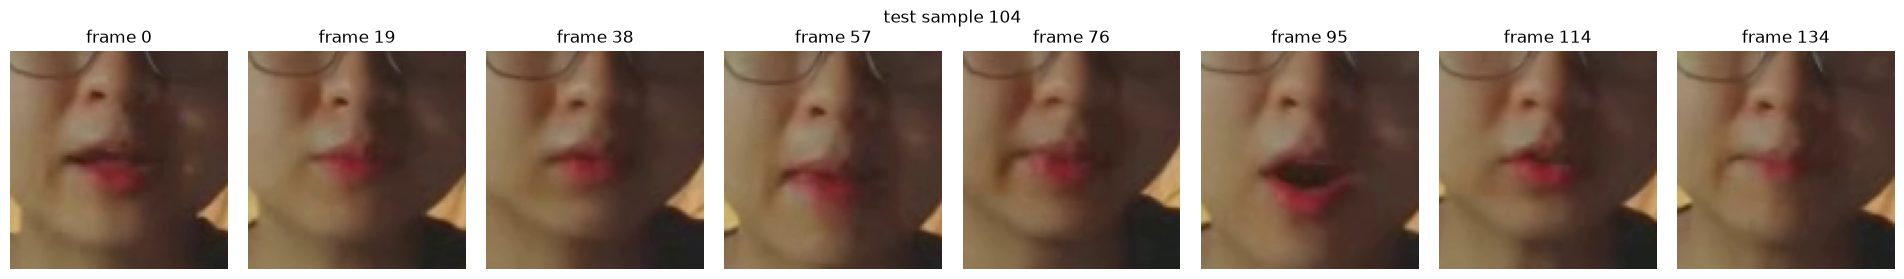

sample_id: Nnd75WTJPpw_00021_000000_3_-1.00
label: khi có người nói chúng mình xấu như cái cách mà mai cồ do đừn bị loại khỏi đội bóng rổ trong trường bị đánh giá thấp
decoded shape: (135, 3, 96, 96)
metadata frame length: 132


In [8]:
show_random_samples(dataset, "train", sample_count=2)
show_random_samples(dataset, "val", sample_count=1)
show_random_samples(dataset, "test", sample_count=1)

## Compare video before and after training augmentation

The augmented tensor is de-normalized only for visualization. The tensor passed to the model remains normalized.

In [12]:
def augment_sample(split_dataset, index, seed=SEED, splits="train"):
    random.seed(seed)
    torch.manual_seed(seed)
    sample, raw_video = decode_dataset_sample(split_dataset, index)
    augmented_video = VideoTransform(splits)(raw_video)
    return sample, raw_video, augmented_video


def show_augmentation_frames(raw_video, augmented_video, frame_count=8):
    indices = np.linspace(0, raw_video.size(0) - 1, frame_count, dtype=int)
    figure, axes = plt.subplots(2, frame_count, figsize=(2.4 * frame_count, 5.2))

    for column, frame_index in enumerate(indices):
        axes[0, column].imshow(frame_to_image(raw_video[frame_index]), cmap="gray")
        axes[0, column].set_title(f"frame {frame_index}")
        axes[0, column].axis("off")

        axes[1, column].imshow(
            frame_to_image(augmented_video[frame_index], normalized=True),
            cmap="gray",
            vmin=0.0,
            vmax=1.0,
        )
        axes[1, column].axis("off")

    axes[0, 0].set_ylabel("Decoded")
    axes[1, 0].set_ylabel("Augmented")
    figure.suptitle("Video before and after training augmentation")
    figure.tight_layout()
    plt.show()

In [13]:
def animate_video_pair(raw_video, augmented_video, fps=25, max_frames=150):
    frame_total = min(raw_video.size(0), augmented_video.size(0))
    frame_indices = np.linspace(
        0, frame_total - 1, min(frame_total, max_frames), dtype=int
    )
    figure, axes = plt.subplots(1, 2, figsize=(8, 4))
    raw_artist = axes[0].imshow(frame_to_image(raw_video[frame_indices[0]]))
    augmented_artist = axes[1].imshow(
        frame_to_image(augmented_video[frame_indices[0]], normalized=True),
        cmap="gray",
        vmin=0.0,
        vmax=1.0,
    )
    axes[0].set_title("Decoded video")
    axes[1].set_title("Training augmentation")

    for axis in axes:
        axis.axis("off")

    def update(position):
        frame_index = frame_indices[position]
        raw_artist.set_data(frame_to_image(raw_video[frame_index]))
        augmented_artist.set_data(
            frame_to_image(augmented_video[frame_index], normalized=True)
        )
        figure.suptitle(f"Frame {frame_index}/{frame_total - 1}")
        return raw_artist, augmented_artist

    video_animation = animation.FuncAnimation(
        figure,
        update,
        frames=len(frame_indices),
        interval=1000 / fps,
        blit=False,
    )
    html = HTML(video_animation.to_jshtml(fps=fps, default_mode="loop"))
    plt.close(figure)
    return html

sample_id: s4VtywMd-Y8_00013_000000_1_-1.00
label: dành cho em là mong lớn dành cho em dành cho niềm đam mê viện với bà vui lắm lại cho sát a
raw video: (300, 3, 96, 96), torch.uint8
augmented video: (300, 1, 88, 88), torch.float32


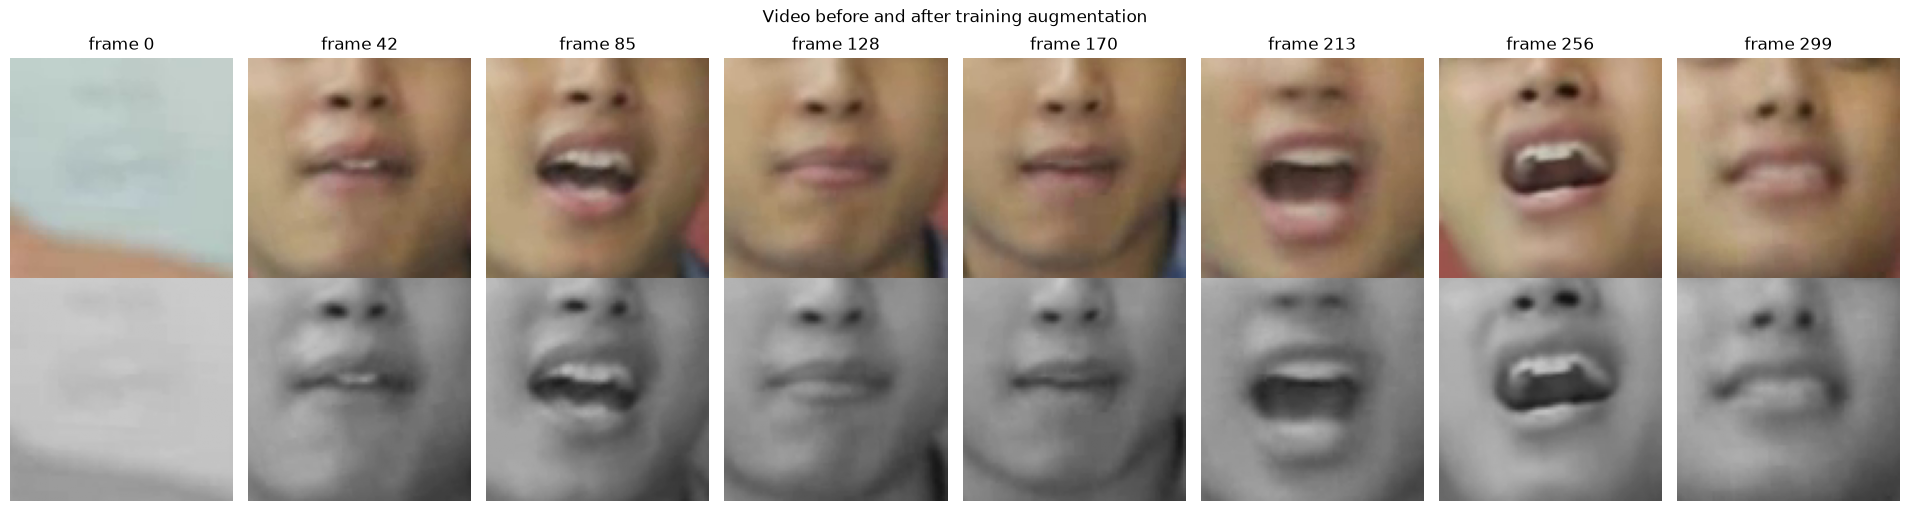

In [ ]:
sample, raw_video, augmented_video = augment_sample(dataset["train"], index=0)

print(f"sample_id: {to_text(sample.get('sample_id', 0))}")
print(f"label: {to_text(sample.get('label', ''))}")
print(f"raw video: {tuple(raw_video.shape)}, {raw_video.dtype}")
print(
    f"augmented video: {tuple(augmented_video.shape)}, "
    f"{augmented_video.dtype}"
)

show_augmentation_frames(raw_video, augmented_video)
display(animate_video_pair(raw_video, augmented_video))

In [ ]:
sample, raw_video, augmented_video = augment_sample(dataset["train"], index=0)

print(f"sample_id: {to_text(sample.get('sample_id', 0))}")
print(f"label: {to_text(sample.get('label', ''))}")
print(f"raw video: {tuple(raw_video.shape)}, {raw_video.dtype}")
print(
    f"augmented video: {tuple(augmented_video.shape)}, "
    f"{augmented_video.dtype}"
)

show_augmentation_frames(raw_video, augmented_video)
display(animate_video_pair(raw_video, augmented_video))